In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib 
import os

C:\Users\Luis\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
os.chdir('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #set directory for desktop
#os.chdir('/Users/sandoval/Library/CloudStorage/Box-Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #this is for when i use my mac instead of my desktop
raw = pd.read_csv('Full Summary Features 7-24-2025.csv') #filtered summary data from madison

In [3]:
#i want to see all the columns so i can specifically pick the features i actually want
    #we are going to make a dataset containing just restrict alongside predictors aka physio
    #then we are going to make another dataset containing just urge to restrict alongside physio
    #we don't want to include any other EMA in our train/test data for each analysis

for col in raw.columns: 
    print(col) 

Unnamed: 0
Time
HR_Mean
HR_Minimum
HR_Maximum
HR_Stdev
HR_RMS
HR_MAV
HR_Median
HR_P25
HR_P75
HR_Slope
EDA_Mean
EDA_Minimum
EDA_Maximum
EDA_Stdev
EDA_RMS
EDA_MAV
EDA_Median
EDA_P25
EDA_P75
EDA_Slope
TEMP_Mean
TEMP_Minimum
TEMP_Maximum
TEMP_Stdev
TEMP_RMS
TEMP_MAV
TEMP_Median
TEMP_P25
TEMP_P75
TEMP_Slope
meanCenteredEDA_Mean
meanCenteredEDA_Minimum
meanCenteredEDA_Maximum
meanCenteredEDA_Stdev
meanCenteredEDA_RMS
meanCenteredEDA_MAV
meanCenteredEDA_Median
meanCenteredEDA_P25
meanCenteredEDA_P75
meanCenteredEDA_Slope
meanCenteredHR_Mean
meanCenteredHR_Minimum
meanCenteredHR_Maximum
meanCenteredHR_Stdev
meanCenteredHR_RMS
meanCenteredHR_MAV
meanCenteredHR_Median
meanCenteredHR_P25
meanCenteredHR_P75
meanCenteredHR_Slope
meanCenteredTEMP_Mean
meanCenteredTEMP_Minimum
meanCenteredTEMP_Maximum
meanCenteredTEMP_Stdev
meanCenteredTEMP_RMS
meanCenteredTEMP_MAV
meanCenteredTEMP_Median
meanCenteredTEMP_P25
meanCenteredTEMP_P75
meanCenteredTEMP_Slope
ethica_time
lag
tdif
cumsumT
ethica_time_utc
day

In [4]:
#descriptives for paper

raw['restrict'].mean()
#raw['restrict'].min()
#raw['restrict'].max()
#raw['restrict'].std()

48.5839915745129

In [5]:
#raw['urge_restrict'].mean()
#raw['urge_restrict'].min()
#raw['urge_restrict'].max()
raw['urge_restrict'].std()

30.810261362815815

In [6]:
#row_nan_count = .isna().sum(axis=1)

raw["urge_restrict"].isna().sum() #71 urge_restrict points missing 
raw["restrict"].isna().sum() #54 restrict items missing
len(raw["urge_restrict"])
raw

,Unnamed: 0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,HR_Median,HR_P25,...,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,PR,unique
0,0,2020-12-09 14:54:00,88.744522,73.17,103.47,6.505839,88.982574,103.47,89.37,83.67,...,0.279661,-1.0,-2.788136,-13.0,26.110169,15.5,0.0,0.0,PR003,1
1,1,2020-12-09 00:24:00,79.124461,51.55,107.33,14.197488,80.387592,107.33,78.45,70.92,...,0.279661,-1.0,18.211864,8.0,7.110169,-3.5,0.0,0.0,PR003,2
2,2,2020-12-08 19:30:00,66.492599,54.12,88.70,8.862043,67.080316,88.70,64.57,60.28,...,0.279661,-1.0,8.211864,-2.0,18.110169,7.5,0.0,0.0,PR003,3
3,3,2020-12-08 17:59:00,60.827888,47.20,73.68,5.746152,61.098580,73.68,61.47,56.02,...,2.279661,1.0,17.211864,7.0,18.110169,7.5,0.0,0.0,PR003,4
4,4,2020-12-07 22:58:00,52.120404,40.58,66.08,5.952649,52.459087,66.08,51.93,48.53,...,-0.720339,-2.0,16.211864,6.0,17.110169,6.5,0.0,0.0,PR003,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1951,59,2022-02-28 14:18:00,101.851703,77.92,187.35,27.662888,105.539974,187.35,89.95,84.03,...,0.741573,0.0,-22.977528,-25.0,-0.314607,1.0,0.0,0.0,PR128,1952
1952,60,2022-02-25 22:40:00,95.832491,73.85,121.93,12.922097,96.699417,121.93,95.38,84.83,...,-7.258427,-8.0,26.022472,24.0,4.685393,6.0,0.0,0.0,PR128,1953
1953,61,2022-02-25 21:11:00,75.666356,63.68,82.35,4.902798,75.824962,82.35,76.73,73.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PR128,1954
1954,62,2022-02-25 18:23:00,83.565743,64.30,123.05,16.279685,85.136075,123.05,78.07,71.42,...,18.741573,18.0,27.022472,25.0,16.685393,18.0,0.0,0.0,PR128,1955


In [7]:
#adding diagnoses

diag = pd.read_csv('ScreeningsR15-EDDiagnosticsSummary_DATA_2024-02-25_1408.csv') #dataframe containing diagnoses by ID
diag["PR"] = diag['record_id_73f3b8'] #making a column to match IDs
diag = diag.filter(['PR', 'currentdx1_ade7bc']) #i want to only merge the current general diagnoses and keep the ID variable
raw = diag.merge(raw, how = 'inner', on = 'PR') #we made it 

raw.head()

,PR,currentdx1_ade7bc,Unnamed: 0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,...,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,unique
0,PR003,1.0,0,2020-12-09 14:54:00,88.744522,73.17,103.47,6.505839,88.982574,103.47,...,0.0,0.279661,-1.0,-2.788136,-13.0,26.110169,15.5,0.0,0.0,1
1,PR003,1.0,1,2020-12-09 00:24:00,79.124461,51.55,107.33,14.197488,80.387592,107.33,...,0.0,0.279661,-1.0,18.211864,8.0,7.110169,-3.5,0.0,0.0,2
2,PR003,1.0,2,2020-12-08 19:30:00,66.492599,54.12,88.70,8.862043,67.080316,88.70,...,0.0,0.279661,-1.0,8.211864,-2.0,18.110169,7.5,0.0,0.0,3
3,PR003,1.0,3,2020-12-08 17:59:00,60.827888,47.20,73.68,5.746152,61.098580,73.68,...,0.0,2.279661,1.0,17.211864,7.0,18.110169,7.5,0.0,0.0,4
4,PR003,1.0,4,2020-12-07 22:58:00,52.120404,40.58,66.08,5.952649,52.459087,66.08,...,0.0,-0.720339,-2.0,16.211864,6.0,17.110169,6.5,0.0,0.0,5


In [8]:
#random seed. I picked 6 because I like 6 and i always pick 6. this is so we get the same results every time
np.random.seed(6)

In [9]:
corrs = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev',  
                    'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median',
                    'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                    'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD',
                    'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope',
                    'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev',
                    'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median',
                    'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope', 'urge_restrict', 'restrict'])

In [10]:
corrs = corrs.rename(columns={"meanCenteredEDA_Mean" : "EDA_Mean",
                      "meanCenteredEDA_Minimum" : "EDA_Minimum",
                      "meanCenteredEDA_Maximum" : "EDA_Maximum",
                      "meanCenteredEDA_Stdev" : "EDA_Stdev",
                      "meanCenteredEDA_RMS" : "EDA_RMS",
                      "meanCenteredEDA_MAD" : "EDA_MAD",
                      "meanCenteredEDA_MAV" : "EDA_MAV",
                      "meanCenteredEDA_Median" : "EDA_Median",
                      "meanCenteredEDA_P25" : "EDA_P25",
                      "meanCenteredEDA_P75" : "EDA_P75",
                      "meanCenteredEDA_Slope" : "EDA_Slope",
                      "meanCenteredHR_Mean" : "HR_Mean",
                      "meanCenteredHR_Minimum" : "HR_Minimum",
                      "meanCenteredHR_Maximum" : "HR_Maximum",
                      "meanCenteredHR_Stdev" : "HR_Stdev",
                      "meanCenteredHR_RMS" : "HR_RMS",
                      "meanCenteredHR_MAD" : "HR_MAD",
                      "meanCenteredHR_MAV" : "HR_MAV",
                      "meanCenteredHR_Median" : "HR_Median",
                      "meanCenteredHR_P25" : "HR_P25",
                      "meanCenteredHR_P75" : "HR_P75",
                      "meanCenteredHR_Slope" : "HR_Slope",
                      "meanCenteredTEMP_Mean" : "TEMP_Mean",
                      "meanCenteredTEMP_Minimum" : "TEM_Minimum",
                      "meanCenteredTEMP_Maximum" : "TEMP_Maximum",
                      "meanCenteredTEMP_Stdev" : "TEMP_Stdev",
                      "meanCenteredTEMP_RMS" : "TEMP_RMS",
                      "meanCenteredTEMP_MAD" : "TEMP_MAD",
                      "meanCenteredTEMP_MAV" : "TEMP_MAV",
                      "meanCenteredTEMP_Median" : "TEMP_Median",
                      "meanCenteredTEMP_P25" : "TEMP_P25",
                      "meanCenteredTEMP_P75" : "TEMP_P75",
                      "meanCenteredTEMP_Slope" : "TEMP_Slope",
                      "urge_restrict" : "urge_restrict",
                      "restrict" : "restrict"})

In [11]:
Corr_Matrix = round(corrs.corr(),2)
print(Corr_Matrix)

               EDA_Mean  EDA_Minimum  EDA_Maximum  EDA_Stdev  EDA_RMS  \
EDA_Mean           1.00         0.86         0.93       0.69     0.92   
EDA_Minimum        0.86         1.00         0.65       0.28     0.70   
EDA_Maximum        0.93         0.65         1.00       0.89     0.92   
EDA_Stdev          0.69         0.28         0.89       1.00     0.77   
EDA_RMS            0.92         0.70         0.92       0.77     1.00   
EDA_MAV            0.88         0.58         0.97       0.90     0.96   
EDA_Median         1.00         0.87         0.90       0.65     0.91   
EDA_P25            0.98         0.93         0.85       0.54     0.87   
EDA_P75            0.99         0.80         0.95       0.76     0.93   
EDA_Slope         -0.03        -0.15         0.12       0.26     0.02   
HR_Mean            0.11         0.07         0.12       0.11     0.15   
HR_Minimum         0.10         0.07         0.12       0.10     0.13   
HR_Maximum         0.07         0.05         0.08  

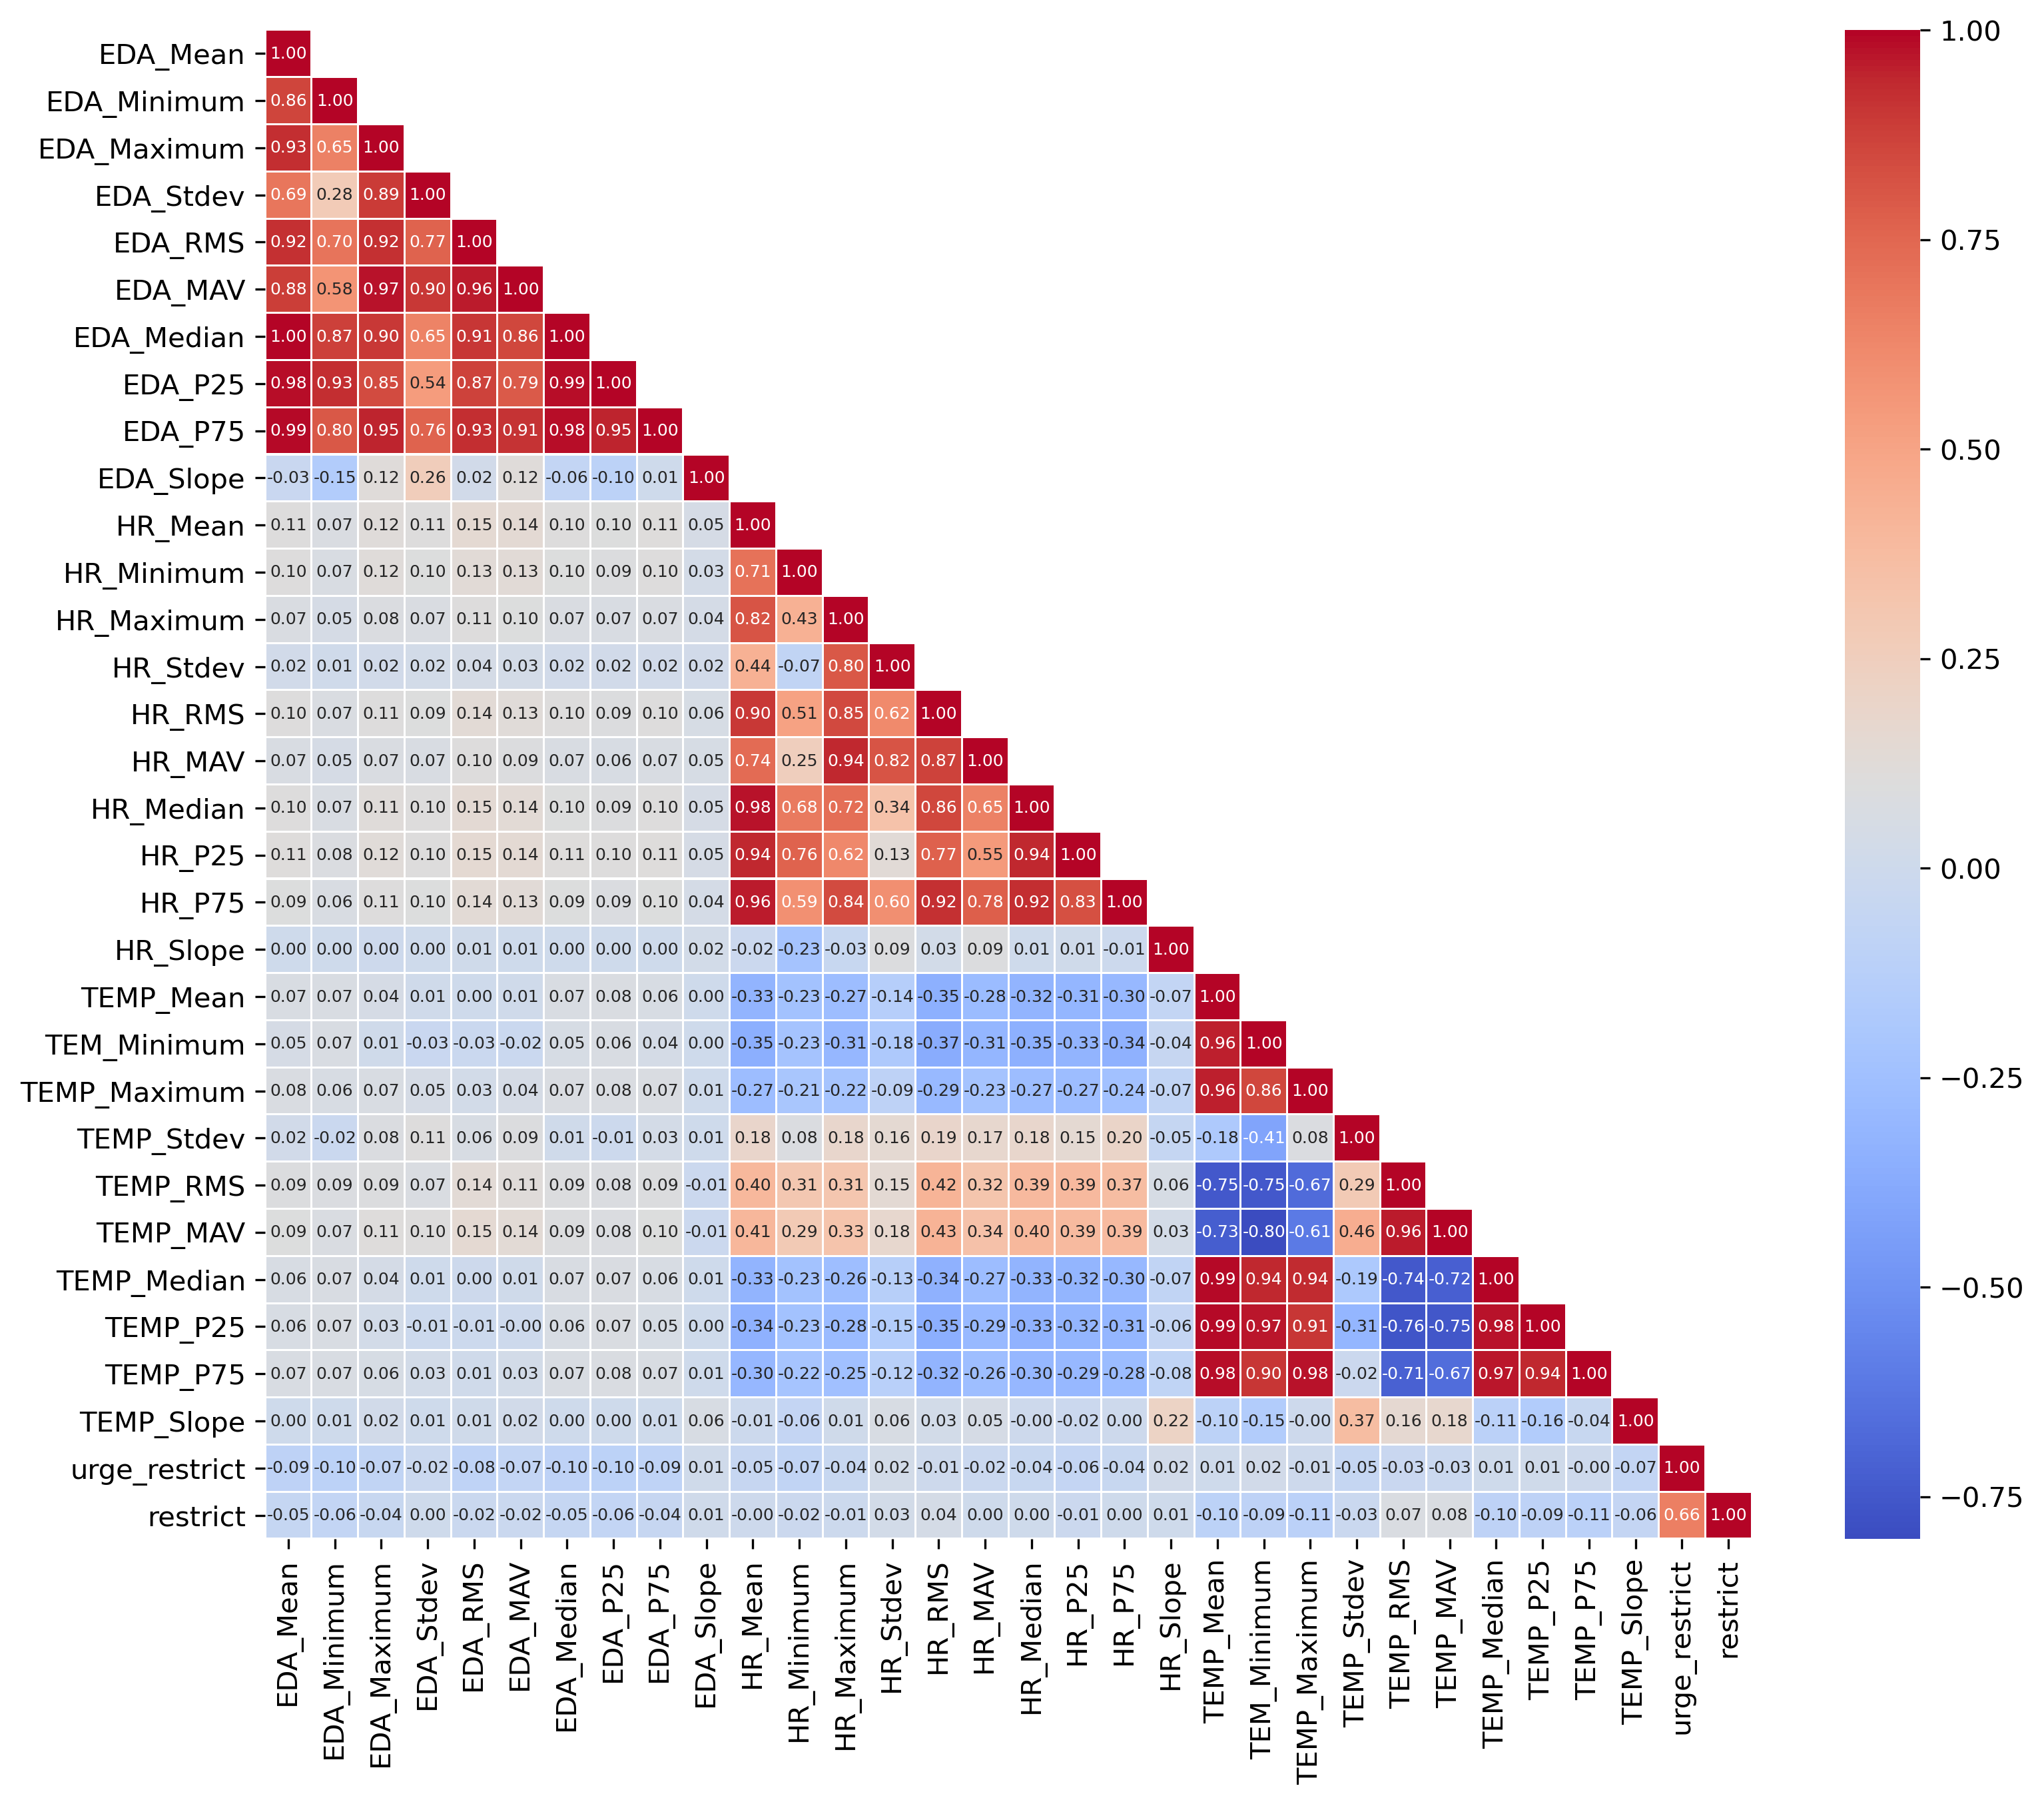

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_full = corrs.corr()

mask = np.zeros_like(correlation_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True
np.fill_diagonal(mask, False)
 
plt.figure(figsize=(12,10), dpi =300)
sns.heatmap(correlation_full,fmt=".2f", linewidth=.5, cmap = 'coolwarm', mask = mask, annot=True,annot_kws={"fontsize": 6})
plt.show()

#the most correlated features EDA are Mean for central tendency and MAV for dispersion for restrict
#the most for HR are RMS for central tendency and Stdev for dispersion for restrict
#for temp, mean for central tendency and MAV for dispersion for restrict

#urge is most associated with EDA MAV for dispersion and Median for central tendency
#HR Mean and Stdev for urge
#TEMP Stdev and RMS for urge

In [13]:
raw['PR'] = raw['PR'].astype('category')
raw['PR']

0       PR003
1       PR003
2       PR003
3       PR003
4       PR003
        ...  
1951    PR128
1952    PR128
1953    PR128
1954    PR128
1955    PR128
Name: PR, Length: 1956, dtype: category
Categories (37, object): ['PR003', 'PR008', 'PR010', 'PR011', ..., 'PR116', 'PR117', 'PR126', 'PR128']

In [14]:
#creating the dataset for predicting urge_restrict from physio alone
urgeData = raw.filter(['PR', 'currentdx1_ade7bc', 'beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 
                       'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 
                       'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 
                       'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 'meanCenteredHR_Maximum', 
                       'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 'meanCenteredHR_MAV', 
                       'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope',
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 
                       'meanCenteredTEMP_Stdev', 'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 
                       'meanCenteredTEMP_Median', 'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope',
                       'urge_restrict'])

urgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(urgeData['urge_restrict'])) #check that NAs exist - if false, we are good

False

In [15]:
restrictData = raw.filter(['PR', 'currentdx1_ade7bc','beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 
                           'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 
                           'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 
                           'meanCenteredEDA_Slope', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 'meanCenteredHR_Maximum', 
                           'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 'meanCenteredHR_MAV', 
                           'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 'meanCenteredHR_Slope', 
                           'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 
                           'meanCenteredTEMP_Stdev', 'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 
                           'meanCenteredTEMP_Median', 'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'meanCenteredTEMP_Slope', 
                           'restrict'])


restrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictData['restrict'])) #check that NAs exist - if false, we are good

False

In [143]:
urgeData['urge_restrict'].groupby(restrictData['PR']).mean()

PR
PR003    82.466102
PR008    43.746269
PR010     1.354839
PR011    46.403361
PR018    69.125000
PR020    29.780702
PR021    55.500000
PR022    81.000000
PR023    47.605263
PR025    59.346535
PR030    50.692308
PR032    91.093023
PR033    79.129032
PR037    53.254902
PR038    66.902174
PR039    15.180556
PR042    22.118812
PR044    29.944444
PR048    16.591549
PR073    10.033333
PR078    37.680000
PR079    40.962963
PR084    85.333333
PR085    72.461538
PR086    53.277778
PR092    39.555556
PR096    35.916667
PR101    79.568966
PR102    90.571429
PR104    93.850000
PR106     6.571429
PR113    73.400000
PR115     7.900000
PR116    71.733333
PR117    33.636364
PR126    78.416667
PR128    56.222222
Name: urge_restrict, dtype: float64

In [145]:
restrictData['restrict'].groupby(restrictData['PR']).std()

PR
PR003     6.911833
PR008    16.922296
PR010     3.976977
PR011     6.320681
PR018    26.351391
PR020     0.606145
PR021    26.755685
PR022          NaN
PR023    22.702667
PR025    12.243176
PR030    11.795805
PR032    25.122843
PR033    18.513713
PR037    16.742653
PR038    13.733437
PR039     3.218905
PR042    11.005525
PR044     6.222718
PR048    21.400697
PR073     5.446184
PR078     5.791373
PR079    14.007121
PR084     3.271085
PR085    12.210756
PR086    19.861348
PR092    19.227956
PR096    34.589366
PR101    16.966537
PR102     5.617455
PR104    18.818804
PR106    17.232306
PR113    12.641202
PR115     2.699794
PR116    13.294353
PR117    28.977107
PR126    10.994797
PR128    14.896279
Name: restrict, dtype: float64

In [18]:
import time
import datetime

urgeData = urgeData.sort_values(by='beepconsec', ascending = True)

restrictData = restrictData.sort_values(by='beepconsec', ascending = True)

In [19]:
#I want to keep urgeData and restrictData as is with the variables that allow me to unify the data later...
#in the meantime I need dataframes without the ID, diagnosis, and beep variables because the cross validation won't run
#this data will be used for cross-validation

urgeX_cross = urgeData.drop(['urge_restrict'], axis=1)
urgey_cross = urgeData.filter(['urge_restrict', 'PR', 'currentdx1_ade7bc','beepconsec']) #make a dataframe containing only urge_restrict variable

restX_cross = restrictData.drop(['restrict'], axis=1)
resty_cross = restrictData.filter(['restrict', 'PR', 'currentdx1_ade7bc','beepconsec'])

In [20]:
#data splitting for final model validation

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5) 

for train_index, test_index in cv.split(urgeX_cross):
    urgeX_train, urgeX_test = urgeX_cross.iloc[train_index, :], urgeX_cross.iloc[test_index,:]
    urgey_train, urgey_test = urgey_cross.iloc[train_index], urgey_cross.iloc[test_index]
    
urgeX_train_clean = urgeX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgeX_test_clean = urgeX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_train_clean = urgey_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_test_clean = urgey_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

urgeX_cv_train = urgeX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
urgey_cv_train = urgey_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from numpy import arange

#we're going to start exclusively with the urge data for now, we'll circle back to the restrict data later 

urgeMod = GradientBoostingRegressor() 

In [22]:
from numpy import mean
from numpy import std
from numpy import absolute

#developing a grid search cross-validation function that will provide us with a dictionary that contains the hyperparameters
#the dictionary with hyperparameters will allow us to automatically plug in our best hyperparameters 
def cross_validation(model, _X, _y, _cv):
    param_grid = {"max_depth" : [2,4,6,8],
                  "min_samples_split" : [2,5,10],
                  "learning_rate" : [0.001, 0.01, 0.1, 1]}
    _scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
    grid_search = GridSearchCV(estimator = model, param_grid = param_grid, cv = _cv, scoring = _scoring, return_train_score = True, refit= 'neg_root_mean_squared_error', n_jobs = -1)
    grid_search.fit(X = _X, y = _y,)
    d = dict()
    d['results'] = pd.DataFrame(grid_search.cv_results_)
    lr = format(grid_search.best_params_).partition("{'learning_rate': ")[2] #alpha parameter
    d['lr'] = lr.partition(",")[0]
    md = format(grid_search.best_params_).partition("'max_depth': ")[2] #L1 ratio parameter
    d['md'] = md.partition(",")[0]
    mss = format(grid_search.best_params_).partition("'min_samples_split': ")[2] #tolerance parameter
    d['mss'] = mss.partition("}")[0]
    ind = format(grid_search.best_index_) #best index - this will be used to find our associated test R2
    d['ind'] = ind
    print("Best parameters : {}".format(grid_search.best_params_))
    return d
           

In [23]:
urgecv_result = cross_validation(urgeMod, urgeX_cv_train, urgey_cv_train, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2}


In [24]:
urgecv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
 0        1.530343      0.782552         0.005401    4.897263e-04   
 1        1.459927      0.640953         0.004801    4.001379e-04   
 2        1.491134      0.673917         0.005201    9.799293e-04   
 3        2.872644      1.409868         0.005201    4.003525e-04   
 4        2.921455      1.362858         0.005201    7.486341e-04   
 5        2.858441      1.281745         0.005401    4.902130e-04   
 6        4.107921      1.602566         0.010802    1.160266e-02   
 7        4.156331      1.789324         0.005801    7.485958e-04   
 8        3.918078      1.944376         0.005201    4.002810e-04   
 9        5.414715      2.610930         0.006801    1.469938e-03   
 10       5.414415      2.621601         0.006802    1.326971e-03   
 11       5.311493      2.552010         0.006402    1.020085e-03   
 12       1.700082      0.911532         0.005401    4.901934e-04   
 13       1.757597     

In [25]:
### now we build the final model for urge - we are using the optimal hyperparameters divulged through the grid search 
### to fit a final model and then test it on the hold-out test set
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import mean_squared_error as mse
from math import sqrt

urgeModTuned = GradientBoostingRegressor(learning_rate = float(urgecv_result['lr']), max_depth = int(urgecv_result['md']), min_samples_split = int(urgecv_result['mss'])).fit(urgeX_train_clean,urgey_train_clean)
urgeyPred = urgeModTuned.predict(urgeX_test_clean)
print('MAE = ' + str(mae(urgey_test_clean,urgeyPred))) #out of sample (OOS) MAE = 25.84
print('R2 = ' + str(r2_score(urgey_test_clean,urgeyPred))) #OOS R2 = -.64
print('RMSE = ' + str(sqrt(mse(urgey_test_clean,urgeyPred)))) # RMSE = 29.13

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 20.77217777374646
R2 = 0.27597638352034626
RMSE = 24.765876470140054


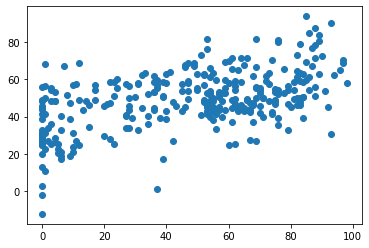

In [26]:
urgeResults = urgey_test_clean
urgeResults['urge_restrict_overall'] = urgeyPred

plt.scatter(urgeResults['urge_restrict'], urgeResults['urge_restrict_overall'])

In [27]:
for train_index, test_index in cv.split(restX_cross):
    restX_train, restX_test = restX_cross.iloc[train_index, :], restX_cross.iloc[test_index,:]
    resty_train, resty_test = resty_cross.iloc[train_index], resty_cross.iloc[test_index]
    
restX_train_clean = restX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restX_test_clean = restX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_train_clean = resty_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_test_clean = resty_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

restX_cv_train = restX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
resty_cv_train = resty_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [28]:
restMod = GradientBoostingRegressor() 
restcv_result = cross_validation(restMod, restX_cv_train, resty_cv_train, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 2}


In [29]:
restcv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
 0        1.631966      0.793339         0.005001    6.325606e-04   
 1        1.790801      0.694014         0.004801    4.001857e-04   
 2        1.656371      0.858841         0.004401    4.899403e-04   
 3        3.044282      1.009772         0.005601    4.901155e-04   
 4        3.197316      1.449105         0.005601    4.899209e-04   
 5        3.238926      1.344366         0.005001    3.234067e-07   
 6        4.532017      1.896586         0.005601    4.900182e-04   
 7        4.229949      1.924696         0.006401    1.855098e-03   
 8        4.275260      1.929532         0.005601    4.902324e-04   
 9        5.850888      2.574626         0.006401    4.899987e-04   
 10       6.100117      2.778528         0.006005    6.373972e-04   
 11       5.837569      3.039940         0.009402    6.830926e-03   
 12       1.774771      0.700547         0.004801    3.999711e-04   
 13       1.909407     

In [30]:
restModTuned = GradientBoostingRegressor(learning_rate = float(restcv_result['lr']), max_depth = int(restcv_result['md']), min_samples_split = int(restcv_result['mss'])).fit(restX_train_clean,resty_train_clean)
restyPred = restModTuned.predict(restX_test_clean)
print('MAE = ' + str(mae(resty_test_clean,restyPred))) #out of sample (OOS) MAE = 33.08
print('R2 = ' + str(r2_score(resty_test_clean,restyPred))) #OOS R2 = -1.67
print('RMSE = ' + str(sqrt(mse(resty_test_clean,restyPred)))) # RMSE = 36.08

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 20.000286226583263
R2 = 0.4299966885184544
RMSE = 25.0633101035558


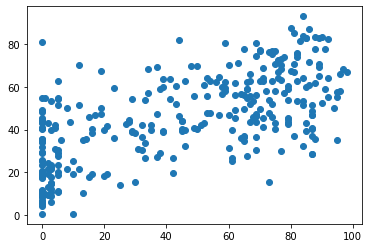

In [31]:
restResults = resty_test_clean
restResults['restrict_overall'] = restyPred

plt.scatter(restResults['restrict'], restResults['restrict_overall'])

In [32]:
###diagnostic-specific models now

pd.set_option("display.max.rows", None)
idiographicDx = raw[["PR","currentdx1_ade7bc"]]
idiographicDx.drop_duplicates(keep='first')



,PR,currentdx1_ade7bc
0,PR003,1.0
118,PR008,2.0
186,PR010,1.0
256,PR011,1.0
376,PR018,1.0
392,PR020,1.0
507,PR021,4.0
518,PR022,2.0
519,PR023,1.0
558,PR025,4.0


In [33]:
idiographicDx

,PR,currentdx1_ade7bc
0,PR003,1.0
1,PR003,1.0
2,PR003,1.0
3,PR003,1.0
4,PR003,1.0
5,PR003,1.0
6,PR003,1.0
7,PR003,1.0
8,PR003,1.0
9,PR003,1.0


In [34]:
restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis

In [35]:
restrictMask = restrictFilter['restrict'].values >= 40
restrictOnly = restrictFilter.loc[restrictMask]
restrictOnly = restrictOnly.rename_axis('PR').reset_index()
restIdList = restrictOnly['PR'].copy()

In [36]:
urgeMask = restrictFilter['urge_restrict'].values >= 40
urgeOnly = restrictFilter.loc[urgeMask]
urgeOnly = urgeOnly.rename_axis('PR').reset_index()
urgeIdList = urgeOnly['PR'].copy()

In [37]:
restIdList = restIdList.tolist()
urgeIdList = urgeIdList.tolist()

In [38]:
idList = restIdList + urgeIdList
idList = set(idList)
idList

{'PR003',
 'PR008',
 'PR011',
 'PR018',
 'PR021',
 'PR022',
 'PR023',
 'PR025',
 'PR030',
 'PR032',
 'PR033',
 'PR037',
 'PR038',
 'PR044',
 'PR078',
 'PR079',
 'PR084',
 'PR085',
 'PR086',
 'PR101',
 'PR102',
 'PR104',
 'PR113',
 'PR116',
 'PR117',
 'PR126',
 'PR128'}

In [39]:
restricterData = raw.loc[raw["PR"].isin(idList)]
len(restricterData['PR'].unique()) #27 cases in restriction analysis

27

In [40]:
#restricterData['urge_restrict'].mean()
#restricterData['urge_restrict'].min()
#restricterData['urge_restrict'].max()
restricterData['urge_restrict'].std()

24.354187649246107

In [41]:
#restricterData['restrict'].mean()
#restricterData['restrict'].min()
#restricterData['restrict'].max()
restricterData['restrict'].std()

24.14175097515067

In [42]:
restricterDx = restricterData.filter(['PR','currentdx1_ade7bc'])

In [43]:
restricterDx = restricterDx.drop_duplicates()
restricterDx['currentdx1_ade7bc'].value_counts()

currentdx1_ade7bc
1.0    12
4.0     9
2.0     6
Name: count, dtype: int64

In [44]:
restricterUrgeData = restricterData.filter(['PR', 'currentdx1_ade7bc', 'beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

restricterRestrictData = restricterData.filter(['PR', 'currentdx1_ade7bc', 'beepconsec','meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

restricterUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restricterUrgeData['urge_restrict'])) 

restricterRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restricterRestrictData['restrict'])) 

False

In [45]:
restricterUrgeData = restricterUrgeData.sort_values(by='beepconsec', ascending = True)

restricterRestrictData = restricterRestrictData.sort_values(by='beepconsec', ascending = True)

In [46]:
restricterUrgeX_cross = restricterUrgeData.drop(['urge_restrict'], axis=1)
restricterUrgey_cross = restricterUrgeData.filter(['urge_restrict', 'PR', 'currentdx1_ade7bc','beepconsec']) #make a dataframe containing only urge_restrict variable

restricterRestX_cross = restricterRestrictData.drop(['restrict'], axis=1)
restricterResty_cross = restricterRestrictData.filter(['restrict', 'PR', 'currentdx1_ade7bc','beepconsec'])

In [47]:
restricterRestX_cross

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredHR_P75,meanCenteredTEMP_Mean,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75
1955,PR128,4.0,1,-0.025919,-0.087461,0.011207,2.013943e-02,0.032821,0.087461,-0.019546,...,-5.707524,0.090098,-0.525116,0.894884,0.394429,0.404509,0.894884,-0.045116,-0.205116,0.484884
117,PR003,1.0,1,0.065352,0.002917,0.120778,1.077259e-02,0.066233,0.120778,0.065691,...,51.729047,-2.269636,-2.820798,-1.560798,0.262720,2.284785,2.820798,-2.320798,-2.420798,-2.140798
375,PR011,1.0,1,10.716578,3.084089,21.966890,5.552098e+00,12.068886,21.966890,11.648262,...,16.854669,-7.740030,-8.054724,-7.254724,0.221478,7.743197,8.054724,-7.774724,-7.934724,-7.594724
391,PR018,1.0,1,-0.112823,-0.216482,0.180755,1.995039e-02,0.114572,0.216482,-0.112688,...,-9.665047,-0.138715,-0.341647,0.118353,0.124863,0.186618,0.341647,-0.141647,-0.241647,-0.041647
662,PR025,4.0,1,1.402597,-0.439245,4.272018,1.000057e+00,1.722491,4.272018,0.984149,...,7.468853,1.371021,1.116935,1.896935,0.205619,1.386348,1.896935,1.296935,1.216935,1.436935
738,PR033,4.0,1,1.910256,1.000787,3.433496,4.449277e-01,1.961366,3.433496,1.957471,...,5.723500,0.161506,0.007112,0.247112,0.060251,0.172375,0.247112,0.187112,0.107112,0.207112
1039,PR038,1.0,1,-1.037859,-1.202684,-0.118739,1.117575e-01,1.043857,1.202684,-1.046380,...,39.655064,-7.704510,-7.945477,-7.145477,0.177652,7.706557,7.945477,-7.765477,-7.825477,-7.665477
1324,PR079,1.0,1,0.017543,-0.280190,0.157946,2.597388e-02,0.031339,0.280190,0.022149,...,45.774316,-1.709649,-2.018903,-1.318903,0.166930,1.717776,2.018903,-1.738903,-1.818903,-1.598903
944,PR037,4.0,1,-0.024593,-0.049741,0.011759,9.590271e-03,0.026396,0.049741,-0.026678,...,18.186949,-1.465517,-1.601043,-1.281043,0.080851,1.467744,1.601043,-1.481043,-1.541043,-1.401043
1398,PR086,1.0,1,-0.171198,-0.175715,0.654488,3.313142e-02,0.174373,0.654488,-0.175715,...,19.816217,1.177713,0.737746,1.467746,0.197844,1.194208,1.467746,1.237746,1.137746,1.297746


In [48]:
cv = TimeSeriesSplit(n_splits=5) 

for train_index, test_index in cv.split(restricterUrgeX_cross):
    restricterUrgeX_train, restricterUrgeX_test = restricterUrgeX_cross.iloc[train_index, :], restricterUrgeX_cross.iloc[test_index,:]
    restricterUrgey_train, restricterUrgey_test = restricterUrgey_cross.iloc[train_index], restricterUrgey_cross.iloc[test_index]
    
restricterUrgeX_train_clean = restricterUrgeX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterUrgeX_test_clean = restricterUrgeX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterUrgey_train_clean = restricterUrgey_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterUrgey_test_clean = restricterUrgey_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

restricterUrgeX_cv_train = restricterUrgeX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterUrgey_cv_train = restricterUrgey_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [49]:
restricterUrgeMod = GradientBoostingRegressor()
restricterUrgecv_result = cross_validation(restricterUrgeMod, restricterUrgeX_cv_train, restricterUrgey_cv_train, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_split': 5}


In [50]:
restricterUrgeModTuned = GradientBoostingRegressor(learning_rate = float(restricterUrgecv_result['lr']), max_depth = int(restricterUrgecv_result['md']), min_samples_split = int(restricterUrgecv_result['mss'])).fit(restricterUrgeX_train_clean,restricterUrgey_train_clean)
restricterUrgeyPred = restricterUrgeModTuned.predict(restricterUrgeX_test_clean)
print('MAE = ' + str(mae(restricterUrgey_test_clean,restricterUrgeyPred))) #out of sample (OOS) MAE = 14.98
print('R2 = ' + str(r2_score(restricterUrgey_test_clean,restricterUrgeyPred))) #OOS R2 = .06
print('RMSE = ' + str(sqrt(mse(restricterUrgey_test_clean,restricterUrgeyPred)))) # RMSE = 19.02

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 14.981733468497124
R2 = 0.055134010697553415
RMSE = 19.017420720288115


In [51]:
cv = TimeSeriesSplit(n_splits=5) 

for train_index, test_index in cv.split(restricterRestX_cross):
    restricterRestX_train, restricterRestX_test = restricterRestX_cross.iloc[train_index, :], restricterRestX_cross.iloc[test_index,:]
    restricterResty_train, restricterResty_test = restricterResty_cross.iloc[train_index], restricterResty_cross.iloc[test_index]
    
restricterRestX_train_clean = restricterRestX_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterRestX_test_clean = restricterRestX_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterResty_train_clean = restricterResty_train.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterResty_test_clean = restricterResty_test.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

restricterRestX_cv_train = restricterRestX_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)
restricterResty_cv_train = restricterResty_cross.drop(['beepconsec', 'PR', 'currentdx1_ade7bc'],axis=1)

In [52]:
restricterRestMod = GradientBoostingRegressor()
restricterRestcv_result = cross_validation(restricterRestMod, restricterRestX_cv_train, restricterResty_cv_train, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.01, 'max_depth': 6, 'min_samples_split': 2}


In [53]:
restricterRestModTuned = GradientBoostingRegressor(learning_rate = float(restricterRestcv_result['lr']), max_depth = int(restricterRestcv_result['md']), min_samples_split = int(restricterRestcv_result['mss'])).fit(restricterRestX_train_clean,restricterResty_train_clean)
restricterRestyPred = restricterRestModTuned.predict(restricterRestX_test_clean)
print('MAE = ' + str(mae(restricterResty_test_clean,restricterRestyPred))) #out of sample (OOS) MAE = 25.84
print('R2 = ' + str(r2_score(restricterResty_test_clean,restricterRestyPred))) #OOS R2 = -.64
print('RMSE = ' + str(sqrt(mse(restricterResty_test_clean,restricterRestyPred)))) # RMSE = 29.13

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 14.953199794510446
R2 = 0.2133407197886107
RMSE = 19.043674131717804


In [54]:
restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis

In [55]:
#coding values: 1 = AN, 2 = BN, 3 = BED, 4 = OSFED... there should  be no BED cases. 
#we will look at AN and BN specifically for now

### starting with the urge data
### we need to filter both the complete dataset for cross-validation and then the time/test split that was already done 
### that's so we maintain the same timepoints in the same folds 



    
bnmask = raw['currentdx1_ade7bc'].values == 2
bn = raw.loc[bnmask]

anmask = raw['currentdx1_ade7bc'].values == 1
an = raw.loc[anmask]

osfedmask = raw['currentdx1_ade7bc'].values == 4
osfed = raw.loc[osfedmask]

restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis
restrictMask = restrictFilter['restrict'].values >= 40
restrictOnly = restrictFilter.loc[restrictMask]
restrictOnly = restrictOnly.rename_axis('PR').reset_index()
restIdList = restrictOnly['PR'].copy()

urgeMask = restrictFilter['urge_restrict'].values >= 40
urgeOnly = restrictFilter.loc[urgeMask]
urgeOnly = urgeOnly.rename_axis('PR').reset_index()
urgeIdList = urgeOnly['PR'].copy()

In [56]:
bn['restrict']

118      45.0
119      78.0
120      75.0
121      75.0
122      78.0
123      80.0
124      77.0
125      74.0
126      16.0
127      71.0
128      84.0
129      73.0
130      76.0
131      78.0
132      78.0
133      74.0
134      78.0
135      74.0
136      77.0
137      84.0
138      81.0
139      81.0
140      81.0
141      93.0
142      93.0
143      93.0
144      90.0
145      87.0
146      79.0
147      76.0
148      77.0
149      79.0
150      63.0
151      13.0
152      84.0
153      89.0
154       NaN
155      85.0
156      84.0
157      84.0
158      77.0
159      68.0
160      68.0
161      67.0
162      92.0
163      80.0
164      82.0
165      67.0
166     100.0
167      86.0
168      86.0
169      84.0
170     100.0
171     100.0
172     100.0
173      37.0
174     100.0
175     100.0
176     100.0
177      81.0
178     100.0
179      88.0
180     100.0
181     100.0
182     100.0
183     100.0
184      82.0
185      78.0
518      84.0
1142     81.0
1143     81.0
1144  

In [57]:
bn.loc[bn['restrict'] >= 40, 'SigRestrict'] = 1
bn.loc[bn['restrict'] < 40, 'SigRestrict'] = 0

<ipython-input-57-5564782d25e3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bn.loc[bn['restrict'] >= 40, 'SigRestrict'] = 1


In [58]:
print(bn['SigRestrict'].sum())
print(bn['SigRestrict'].size)

172.0
351


In [59]:
bn['urge_restrict'].mean()
#bn['urge_restrict'].min()
#bn['urge_restrict'].max()
#bn['urge_restrict'].std()

34.42397660818713

In [60]:
bn['restrict'].mean()
#bn['restrict'].min()
#bn['restrict'].max()
#bn['restrict'].std()

42.19825072886297

In [61]:
#full dataset for final model validation on BN only 
    
bn_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 2
bn_urgeX = urgeX_cross.loc[bn_urge_mask]
bn_urgeX = bn_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey = urgey_cross.loc[bn_urge_mask]
bn_urgey = bn_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [62]:
#for train_index, test_index in cv.split(urgeX_cross):
    #urgeX_train, urgeX_test = urgeX_cross.iloc[train_index, :], urgeX_cross.iloc[test_index,:]
    #urgey_train, urgey_test = urgey_cross.iloc[train_index], urgey_cross.iloc[test_index]
    
#now we're filtering the BN cases in the train/test splits

bn_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 2
bn_urgeX_train = urgeX_train.loc[bn_urgeX_train_mask]
bn_urgeX_train = bn_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 2
bn_urgeX_test = urgeX_test.loc[bn_urgeX_test_mask]
bn_urgeX_test = bn_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 2
bn_urgey_train = urgey_train.loc[bn_urgey_train_mask]
bn_urgey_train = bn_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 2
bn_urgey_test = urgey_test.loc[bn_urgey_test_mask]
bn_urgey_test = bn_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [63]:
#ANALYSIS FOR BN
bnUrgeMod = GradientBoostingRegressor() 
bnUrgecv_result = cross_validation(bnUrgeMod, bn_urgeX, bn_urgey, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_split': 10}


In [64]:
bnUrgeModTuned = GradientBoostingRegressor(learning_rate = float(bnUrgecv_result['lr']), max_depth = int(bnUrgecv_result['md']), min_samples_split = int(bnUrgecv_result['mss'])).fit(bn_urgeX_train,bn_urgey_train)
bnUrgeyPred = bnUrgeModTuned.predict(bn_urgeX_test)
print('MAE = ' + str(mae(bn_urgey_test,bnUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(bn_urgey_test,bnUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(bn_urgey_test,bnUrgeyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 21.98242708947016
R2 = -0.03964028385546592
RMSE = 24.693723491092253


In [65]:
urge_bn_Results = bn_urgey_test
urge_bn_Results['urge_restrict_bn'] = bnUrgeyPred
urge_bn_Results = pd.merge(urge_bn_Results, urgeResults, left_index=True, right_index=True, how='inner')


In [66]:
#full dataset for final model validation on BN only 
    
bn_rest_mask = restX_cross['currentdx1_ade7bc'].values == 2
bn_restX = restX_cross.loc[bn_rest_mask]
bn_restX = bn_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty = resty_cross.loc[bn_rest_mask]
bn_resty = bn_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the BN cases in the train/test splits

bn_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 2
bn_restX_train = restX_train.loc[bn_restX_train_mask]
bn_restX_train = bn_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 2
bn_restX_test = restX_test.loc[bn_restX_test_mask]
bn_restX_test = bn_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 2
bn_resty_train = resty_train.loc[bn_resty_train_mask]
bn_resty_train = bn_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

bn_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 2
bn_resty_test = resty_test.loc[bn_resty_test_mask]
bn_resty_test = bn_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [67]:
#ANALYSIS FOR BN
bnRestMod = GradientBoostingRegressor() 
bnRestcv_result = cross_validation(bnRestMod, bn_restX, bn_resty, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.01, 'max_depth': 8, 'min_samples_split': 10}


In [68]:
bnRestcv_result

{'results':     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
 0        0.276461      0.115493         0.005001    2.431402e-07   
 1        0.280263      0.108508         0.005201    9.800948e-04   
 2        0.282663      0.109825         0.005001    6.325606e-04   
 3        0.509114      0.214319         0.004601    4.899014e-04   
 4        0.502312      0.220131         0.005001    6.327867e-04   
 5        0.488509      0.213994         0.005001    6.323344e-04   
 6        0.701157      0.318164         0.006402    2.800584e-03   
 7        0.693956      0.317534         0.005201    7.486087e-04   
 8        0.669350      0.314947         0.005001    9.536743e-08   
 9        0.906704      0.464971         0.005001    5.091228e-07   
 10       0.847592      0.416306         0.005201    7.484429e-04   
 11       0.811583      0.406384         0.004801    3.998757e-04   
 12       0.283264      0.105705         0.004801    3.998995e-04   
 13       0.283065     

In [69]:
bnRestModTuned = GradientBoostingRegressor(learning_rate = float(bnRestcv_result['lr']), max_depth = int(bnRestcv_result['md']), min_samples_split = int(bnRestcv_result['mss'])).fit(bn_restX_train,bn_resty_train)
bnRestyPred = bnRestModTuned.predict(bn_restX_test)
print('MAE = ' + str(mae(bn_resty_test,bnRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(bn_resty_test,bnRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(bn_resty_test,bnRestyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 24.597068145073866
R2 = -0.9287975920515956
RMSE = 29.42623848667228


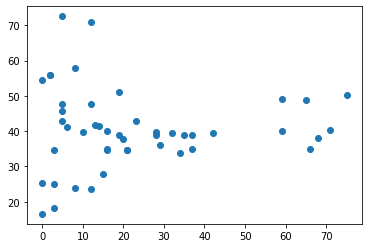

In [70]:
rest_bn_Results = bn_resty_test
rest_bn_Results['restrict_bn'] = bnRestyPred


plt.scatter(rest_bn_Results['restrict'], rest_bn_Results['restrict_bn'])

In [71]:
rest_bn_Results

,restrict,restrict_bn
1439,28.0,39.882669
1236,0.0,25.439747
1182,3.0,25.106221
1181,8.0,23.821758
1438,42.0,39.437368
1180,14.0,41.456120
1437,29.0,36.191310
1436,10.0,39.634224
1235,0.0,16.561494
1179,16.0,35.000032


In [72]:
rest_bn_Results = pd.merge(rest_bn_Results, restResults, left_index=True, right_index=True, how='inner')

In [73]:
rest_bn_Results

,restrict_x,restrict_bn,restrict_y,restrict_overall
1439,28.0,39.882669,28.0,44.643206
1236,0.0,25.439747,0.0,4.016636
1182,3.0,25.106221,3.0,23.278119
1181,8.0,23.821758,8.0,21.689301
1438,42.0,39.437368,42.0,26.844629
1180,14.0,41.456120,14.0,35.365578
1437,29.0,36.191310,29.0,54.339413
1436,10.0,39.634224,10.0,25.233895
1235,0.0,16.561494,0.0,4.917939
1179,16.0,35.000032,16.0,38.256880


In [74]:
#full dataset for final model validation on an only 
    
an_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 1
an_urgeX = urgeX_cross.loc[an_urge_mask]
an_urgeX = an_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey = urgey_cross.loc[an_urge_mask]
an_urgey = an_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 1
an_urgeX_train = urgeX_train.loc[an_urgeX_train_mask]
an_urgeX_train = an_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 1
an_urgeX_test = urgeX_test.loc[an_urgeX_test_mask]
an_urgeX_test = an_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 1
an_urgey_train = urgey_train.loc[an_urgey_train_mask]
an_urgey_train = an_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 1
an_urgey_test = urgey_test.loc[an_urgey_test_mask]
an_urgey_test = an_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [75]:
an.loc[an['restrict'] >= 40, 'SigRestrict'] = 1
an.loc[an['restrict'] < 40, 'SigRestrict'] = 0

<ipython-input-75-ebcbc93cb8b3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  an.loc[an['restrict'] >= 40, 'SigRestrict'] = 1


In [76]:
print(an['SigRestrict'].sum())
print(an['SigRestrict'].size)

535.0
966


In [77]:
#an['urge_restrict'].mean()
#an['urge_restrict'].min()
#an['urge_restrict'].max()
an['urge_restrict'].std()

30.31407729684641

In [78]:
an['restrict'].mean()
#an['restrict'].min()
#an['restrict'].max()
#an['restrict'].std()

46.62632696390658

In [79]:
#ANALYSIS FOR AN
anUrgeMod = GradientBoostingRegressor() 
anUrgecv_result = cross_validation(anUrgeMod, an_urgeX, an_urgey, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 5}


In [80]:
anUrgeModTuned = GradientBoostingRegressor(learning_rate = float(anUrgecv_result['lr']), max_depth = int(anUrgecv_result['md']), min_samples_split = int(anUrgecv_result['mss'])).fit(an_urgeX_train,an_urgey_train)
anUrgeyPred = anUrgeModTuned.predict(an_urgeX_test)
print('MAE = ' + str(mae(an_urgey_test,anUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(an_urgey_test,anUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(an_urgey_test,anUrgeyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 19.19599116066481
R2 = 0.3800836152842001
RMSE = 23.043155130764124


In [81]:
urge_an_Results = an_urgey_test
urge_an_Results['urge_restrict_an'] = anUrgeyPred
urge_an_Results = pd.merge(urge_an_Results, urgeResults, left_index=True, right_index=True, how='inner')

urge_an_Results

,urge_restrict_x,urge_restrict_an,urge_restrict_y,urge_restrict_overall
413,27.0,40.331620,27.0,33.651592
282,69.0,22.469365,69.0,26.983543
527,32.0,50.639129,32.0,62.374674
21,76.0,60.878138,76.0,54.052567
1343,28.0,54.045170,28.0,50.046566
967,69.0,55.693035,69.0,55.781012
1668,76.0,61.756689,76.0,51.912404
281,63.0,46.872537,63.0,43.111386
1064,3.0,45.858364,3.0,48.113685
280,62.0,59.324177,62.0,47.007259


In [82]:
#now we do AN

#full dataset for final model validation on an only 
    
an_rest_mask = restX_cross['currentdx1_ade7bc'].values == 1
an_restX = restX_cross.loc[an_rest_mask]
an_restX = an_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty = resty_cross.loc[an_rest_mask]
an_resty = an_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the an cases in the train/test splits

an_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 1
an_restX_train = restX_train.loc[an_restX_train_mask]
an_restX_train = an_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 1
an_restX_test = restX_test.loc[an_restX_test_mask]
an_restX_test = an_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 1
an_resty_train = resty_train.loc[an_resty_train_mask]
an_resty_train = an_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

an_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 1
an_resty_test = resty_test.loc[an_resty_test_mask]
an_resty_test = an_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [83]:
#ANALYSIS FOR AN
anRestMod = GradientBoostingRegressor() 
anRestcv_result = cross_validation(anRestMod, an_restX, an_resty, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 2}


In [84]:
anRestModTuned = GradientBoostingRegressor(learning_rate = float(anRestcv_result['lr']), max_depth = int(anRestcv_result['md']), min_samples_split = int(anRestcv_result['mss'])).fit(an_restX_train,an_resty_train)
anRestyPred = anRestModTuned.predict(an_restX_test)
print('MAE = ' + str(mae(an_resty_test,anRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(an_resty_test,anRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(an_resty_test,anRestyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 18.062559835412788
R2 = 0.4243804466114083
RMSE = 26.468114579856632


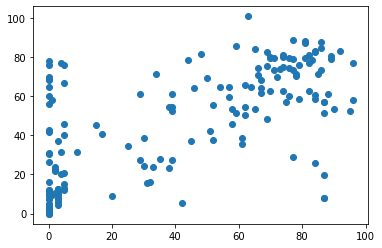

In [85]:
rest_an_Results = an_resty_test
rest_an_Results['restrict_an'] = anRestyPred
rest_an_Results = pd.merge(rest_an_Results, restResults, left_index=True, right_index=True, how='inner')

plt.scatter(rest_an_Results['restrict_x'], rest_an_Results['restrict_an'])

In [86]:
rest_an_Results

,restrict_x,restrict_an,restrict_y,restrict_overall
413,0.0,16.037676,0.0,6.291132
1344,38.0,54.438205,38.0,58.977332
968,46.0,64.106598,46.0,62.966376
1064,4.0,20.507115,4.0,41.955439
1343,15.0,45.410376,15.0,45.766075
967,34.0,71.435791,34.0,57.018532
527,61.0,35.791166,61.0,39.779347
281,69.0,75.658478,69.0,74.737954
21,96.0,58.254134,96.0,58.010894
1668,51.0,42.424036,51.0,42.166422


In [87]:
#full dataset for final model validation on OSFED only 
    
osfed_urge_mask = urgeX_cross['currentdx1_ade7bc'].values == 4
osfed_urgeX = urgeX_cross.loc[osfed_urge_mask]
osfed_urgeX = osfed_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey = urgey_cross.loc[osfed_urge_mask]
osfed_urgey = osfed_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgeX_train_mask = urgeX_train['currentdx1_ade7bc'].values == 4
osfed_urgeX_train = urgeX_train.loc[osfed_urgeX_train_mask]
osfed_urgeX_train = osfed_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgeX_test_mask = urgeX_test['currentdx1_ade7bc'].values == 4
osfed_urgeX_test = urgeX_test.loc[osfed_urgeX_test_mask]
osfed_urgeX_test = osfed_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey_train_mask = urgey_train['currentdx1_ade7bc'].values == 4
osfed_urgey_train = urgey_train.loc[osfed_urgey_train_mask]
osfed_urgey_train = osfed_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_urgey_test_mask = urgey_test['currentdx1_ade7bc'].values == 4
osfed_urgey_test = urgey_test.loc[osfed_urgey_test_mask]
osfed_urgey_test = osfed_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [88]:
osfed.loc[osfed['restrict'] >= 40, 'SigRestrict'] = 1
osfed.loc[osfed['restrict'] < 40, 'SigRestrict'] = 0

<ipython-input-88-f5e4fb267185>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osfed.loc[osfed['restrict'] >= 40, 'SigRestrict'] = 1


In [89]:
print(osfed['SigRestrict'].sum())
print(osfed['SigRestrict'].size)

430.0
639


In [90]:
#osfed['urge_restrict'].mean()
#osfed['urge_restrict'].min()
#osfed['urge_restrict'].max()
osfed['urge_restrict'].std()

27.356352240565297

In [91]:
osfed['restrict'].mean()
#osfed['restrict'].min()
#osfed['restrict'].max()
#osfed['restrict'].std()

55.15472312703583

In [92]:
#ANALYSIS FOR osfed
osfedUrgeMod = GradientBoostingRegressor() 
osfedUrgecv_result = cross_validation(osfedUrgeMod, osfed_urgeX, osfed_urgey, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_split': 2}


In [93]:
osfedUrgeModTuned = GradientBoostingRegressor(learning_rate = float(osfedUrgecv_result['lr']), max_depth = int(osfedUrgecv_result['md']), min_samples_split = int(osfedUrgecv_result['mss'])).fit(osfed_urgeX_train,osfed_urgey_train)
osfedUrgeyPred = osfedUrgeModTuned.predict(osfed_urgeX_test)
print('MAE = ' + str(mae(osfed_urgey_test,osfedUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(osfed_urgey_test,osfedUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(osfed_urgey_test,osfedUrgeyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 15.77125115624132
R2 = 0.13545321142797595
RMSE = 20.628416640863044


Text(0, 0.5, 'OSFED Model Predicted Values')

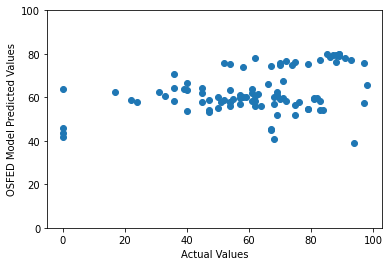

In [94]:
urge_osfed_Results = osfed_urgey_test
urge_osfed_Results['urge_restrict_osfed'] = osfedUrgeyPred
urge_osfed_Results = pd.merge(urge_osfed_Results, urgeResults, left_index=True, right_index=True, how='inner')


plt.scatter(urge_osfed_Results['urge_restrict_x'], urge_osfed_Results['urge_restrict_osfed'])
plt.ylim(0,100)
plt.xlabel("Actual Values")
plt.ylabel("OSFED Model Predicted Values")

Text(0, 0.5, 'Overall Model Predicted Values')

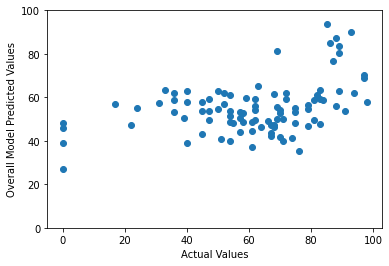

In [95]:
plt.scatter(urge_osfed_Results['urge_restrict_x'], urge_osfed_Results['urge_restrict_overall'])
plt.ylim(0,100)
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")

In [96]:
osfed_rest_mask = restX_cross['currentdx1_ade7bc'].values == 4
osfed_restX = restX_cross.loc[osfed_rest_mask]
osfed_restX = osfed_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty = resty_cross.loc[osfed_rest_mask]
osfed_resty = osfed_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the osfed cases in the train/test splits

osfed_restX_train_mask = restX_train['currentdx1_ade7bc'].values == 4
osfed_restX_train = restX_train.loc[osfed_restX_train_mask]
osfed_restX_train = osfed_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_restX_test_mask = restX_test['currentdx1_ade7bc'].values == 4
osfed_restX_test = restX_test.loc[osfed_restX_test_mask]
osfed_restX_test = osfed_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty_train_mask = resty_train['currentdx1_ade7bc'].values == 4
osfed_resty_train = resty_train.loc[osfed_resty_train_mask]
osfed_resty_train = osfed_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

osfed_resty_test_mask = resty_test['currentdx1_ade7bc'].values == 4
osfed_resty_test = resty_test.loc[osfed_resty_test_mask]
osfed_resty_test = osfed_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [97]:
osfed_resty_test.count()

restrict    95
dtype: int64

In [98]:
osfed_restX_test.count()

meanCenteredEDA_Mean        95
meanCenteredEDA_Minimum     95
meanCenteredEDA_Maximum     95
meanCenteredEDA_Stdev       95
meanCenteredEDA_RMS         95
meanCenteredEDA_MAV         95
meanCenteredEDA_Median      95
meanCenteredEDA_P25         95
meanCenteredEDA_P75         95
meanCenteredEDA_Slope       95
meanCenteredHR_Mean         95
meanCenteredHR_Minimum      95
meanCenteredHR_Maximum      95
meanCenteredHR_Stdev        95
meanCenteredHR_RMS          95
meanCenteredHR_MAV          95
meanCenteredHR_Median       95
meanCenteredHR_P25          95
meanCenteredHR_P75          95
meanCenteredHR_Slope        95
meanCenteredTEMP_Mean       95
meanCenteredTEMP_Minimum    95
meanCenteredTEMP_Maximum    95
meanCenteredTEMP_Stdev      95
meanCenteredTEMP_RMS        95
meanCenteredTEMP_MAV        95
meanCenteredTEMP_Median     95
meanCenteredTEMP_P25        95
meanCenteredTEMP_P75        95
meanCenteredTEMP_Slope      95
dtype: int64

In [99]:
osfedRestMod = GradientBoostingRegressor() 
osfedRestcv_result = cross_validation(osfedRestMod, osfed_restX, osfed_resty, cv) #this does the cross validation

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 10}


In [100]:
osfedRestModTuned = GradientBoostingRegressor(learning_rate = float(osfedRestcv_result['lr']), max_depth = int(osfedRestcv_result['md']), min_samples_split = int(osfedRestcv_result['mss'])).fit(osfed_restX_train,osfed_resty_train)
osfedRestyPred = osfedRestModTuned.predict(osfed_restX_test)
print('MAE = ' + str(mae(osfed_resty_test,osfedRestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(osfed_resty_test,osfedRestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(osfed_resty_test,osfedRestyPred)))) # RMSE = 43.70

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MAE = 17.665435949363278
R2 = -0.046649125310861184
RMSE = 24.402927652298086


Text(0, 0.5, 'OSFED Model Predicted Values')

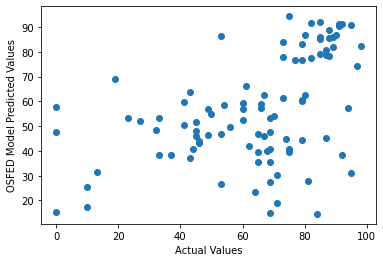

In [101]:
rest_osfed_Results = osfed_resty_test
rest_osfed_Results['restrict_osfed'] = osfedRestyPred
rest_osfed_Results = pd.merge(rest_osfed_Results, restResults, left_index=True, right_index=True, how='inner')


plt.scatter(rest_osfed_Results['restrict_x'], rest_osfed_Results['restrict_osfed'])
plt.xlabel("Actual Values")
plt.ylabel("OSFED Model Predicted Values")

Text(0, 0.5, 'Overall Model Predicted Values')

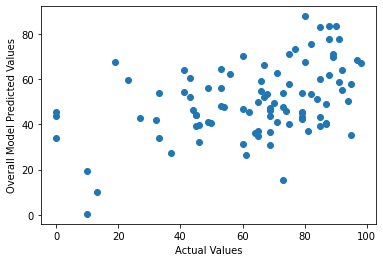

In [102]:
plt.scatter(rest_osfed_Results['restrict_x'], rest_osfed_Results['restrict_overall'])
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")

In [103]:
urgeData

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,meanCenteredTEMP_Slope,urge_restrict
1955,PR128,4.0,1,-0.025919,-0.087461,0.011207,2.013943e-02,0.032821,0.087461,-0.019546,...,-0.525116,0.894884,0.394429,0.404509,0.894884,-0.045116,-0.205116,0.484884,-1.747041e-12,63.0
117,PR003,1.0,1,0.065352,0.002917,0.120778,1.077259e-02,0.066233,0.120778,0.065691,...,-2.820798,-1.560798,0.262720,2.284785,2.820798,-2.320798,-2.420798,-2.140798,6.031525e-13,91.0
1039,PR038,1.0,1,-1.037859,-1.202684,-0.118739,1.117575e-01,1.043857,1.202684,-1.046380,...,-7.945477,-7.145477,0.177652,7.706557,7.945477,-7.765477,-7.825477,-7.665477,9.029768e-13,33.0
1265,PR073,2.0,1,-0.840773,-0.907049,-0.817388,1.632438e-02,0.840932,0.907049,-0.837882,...,-3.841141,-1.701141,0.596943,3.071568,3.841141,-3.121141,-3.601141,-2.581141,3.311553e-12,60.0
944,PR037,4.0,1,-0.024593,-0.049741,0.011759,9.590271e-03,0.026396,0.049741,-0.026678,...,-1.601043,-1.281043,0.080851,1.467744,1.601043,-1.481043,-1.541043,-1.401043,-1.076508e-13,61.0
1635,PR102,4.0,1,-0.036773,-0.094810,-0.007695,1.008921e-02,0.038132,0.094810,-0.037160,...,-0.637806,0.042194,0.158038,0.310050,0.637806,-0.257806,-0.387806,-0.137806,-2.971512e-13,95.0
833,PR039,4.0,1,-0.237310,-0.289999,0.104699,2.786037e-02,0.238940,0.289999,-0.241302,...,-0.286564,0.213436,0.103069,0.103059,0.286564,-0.016564,-0.076564,0.043436,4.687841e-13,0.0
1324,PR079,1.0,1,0.017543,-0.280190,0.157946,2.597388e-02,0.031339,0.280190,0.022149,...,-2.018903,-1.318903,0.166930,1.717776,2.018903,-1.738903,-1.818903,-1.598903,2.559842e-13,56.0
738,PR033,4.0,1,1.910256,1.000787,3.433496,4.449277e-01,1.961366,3.433496,1.957471,...,0.007112,0.247112,0.060251,0.172375,0.247112,0.187112,0.107112,0.207112,2.503987e-14,79.0
1404,PR084,2.0,1,16.313043,12.137970,23.561604,2.253494e+00,16.467893,23.561604,15.646235,...,1.239283,1.699283,0.098956,1.454331,1.699283,1.459283,1.379283,1.509283,-3.333300e-13,92.0


In [104]:
#testing if this works with the idiographic models

PRList = list(urgeData['PR'].unique())
resultsUrgeList = []
resultsRestrictList = []
restDict = []

for PR in PRList:
    curRestrictData = restrictData[restrictData['PR'] == PR]
    curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curRestrictData) <15) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:   
        idio_rest_mask = restX_cross['PR'].isin([PR])
        idio_restX = restX_cross.loc[idio_rest_mask]
        idio_restX = idio_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty = resty_cross.loc[idio_rest_mask]
        idio_resty = idio_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        #now we're filtering the an cases in the train/test splits
        
        idio_restX_train_mask = restX_train['PR'].isin([PR])
        idio_restX_train = restX_train.loc[idio_restX_train_mask]
        idio_restX_train = idio_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        idio_restX_test_mask = restX_test['PR'].isin([PR])
        idio_restX_test = restX_test.loc[idio_restX_test_mask]
        idio_restX_test = idio_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty_train_mask = resty_train['PR'].isin([PR])
        idio_resty_train = resty_train.loc[idio_resty_train_mask]
        idio_resty_train = idio_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_resty_test_mask = resty_test['PR'].isin([PR])
        idio_resty_test = resty_test.loc[idio_resty_test_mask]
        idio_resty_test = idio_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        if (len(idio_resty_test) == 0 ) :
            print('Skipping ' + PR + ' due to lack of holdout set')
        else:
            idioRestMod = GradientBoostingRegressor()
            idioRestcv_result = cross_validation(idioRestMod, idio_restX, idio_resty, cv) #this does the cross validation
            idioRestModTuned = GradientBoostingRegressor(learning_rate = float(idioRestcv_result['lr']), 
                                                         max_depth = int(idioRestcv_result['md']), 
                                                         min_samples_split = int(idioRestcv_result['mss'])).fit(idio_restX_train,idio_resty_train)
            idioRestyPred = idioRestModTuned.predict(idio_restX_test)
            
            print(PR)
            print('MAE = ' + str(mae(idio_resty_test,idioRestyPred))) 
            print('R2 = ' + str(r2_score(idio_resty_test,idioRestyPred))) 
            print('RMSE = ' + str(sqrt(mse(idio_resty_test,idioRestyPred))))
            
            results = idio_resty_test
            results['restrict_prediction'] = idioRestyPred
            results['participant_id'] = PR
            restDict.append(results)

<ipython-input-104-1d7d367c65e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 10}
PR128
MAE = 17.482075647099457
R2 = -1.9451910667654304
RMSE = 19.401671841449378


<ipython-input-104-1d7d367c65e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 5}


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
<ipython-input-104-1d7d367c65e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-104-1d7d367c65e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

Best parameters : {'learning_rate': 0.001, 'max_depth': 2, 'min_samples_split': 2}
PR116
MAE = 8.624176995912054
R2 = -0.0339633679975635
RMSE = 11.017005005573912
Skipping PR022 due to lack of data


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 5}
PR048
MAE = 15.766609624838495
R2 = -6.201143395507008
RMSE = 17.10512297852367
Skipping PR117 due to lack of data


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
<ipython-input-104-1d7d367c65e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


In [105]:
restDict

[      restrict  restrict_prediction participant_id
 1901      49.0            58.735715          PR128
 1900      50.0            59.154629          PR128
 1899      32.0            58.306743          PR128
 1898      23.0            58.121945          PR128
 1897      33.0            57.272354          PR128
 1895      41.0            58.586494          PR128
 1896      41.0            59.615972          PR128
 1894      66.0            58.306743          PR128
 1893      49.0            60.026904          PR128
 1892      43.0            58.306743          PR128,
     restrict  restrict_prediction participant_id
 21      96.0            84.641999          PR003
 19      87.0            82.891419          PR003
 17      87.0            83.823114          PR003
 18      87.0            83.823114          PR003
 20      87.0            82.891419          PR003
 16      88.0            84.365566          PR003
 15      87.0            83.373747          PR003
 14      90.0            84

In [106]:
restResultDict = pd.concat(restDict)

In [107]:
RestAN = pd.merge(restResultDict, rest_an_Results, left_index = True, right_index = True, how="left")

In [108]:
RestBN = pd.merge(restResultDict, rest_bn_Results, left_index = True, right_index = True, how="left")

In [109]:
RestOSFED = pd.merge(restResultDict, rest_osfed_Results, left_index = True, right_index = True, how="left")

In [110]:
RestAN = RestAN.dropna()
RestBN = RestBN.dropna()
RestOSFED = RestOSFED.dropna()

In [111]:
RestOSFED

,restrict,restrict_prediction,participant_id,restrict_x,restrict_osfed,restrict_y,restrict_overall
1901,49.0,58.735715,PR128,49.0,56.925315,49.0,55.937420
1900,50.0,59.154629,PR128,50.0,55.068883,50.0,40.412261
1899,32.0,58.306743,PR128,32.0,48.486855,32.0,42.020713
1898,23.0,58.121945,PR128,23.0,53.463483,23.0,59.343277
1897,33.0,57.272354,PR128,33.0,53.414187,33.0,54.007909
1895,41.0,58.586494,PR128,41.0,50.277840,41.0,54.448736
1896,41.0,59.615972,PR128,41.0,59.663917,41.0,63.843862
1894,66.0,58.306743,PR128,66.0,59.043074,66.0,54.896921
1893,49.0,60.026904,PR128,49.0,46.553240,49.0,40.863353
1892,43.0,58.306743,PR128,43.0,63.887299,43.0,60.462079


In [112]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'restrict_prediction',
        'diagnostic': 'restrict_an',
        'overall': 'restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [113]:
an_rest_outcomes = calculate_metrics_per_participant(RestAN)
print(an_rest_outcomes)

  participant_id    idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR003  -0.111682   4.139881   5.255453     -54.745093   
1          PR010   0.000000   1.448742   1.450323       0.000000   
2          PR011  -0.576998   5.369549   6.559770      -1.853109   
3          PR020   0.024992   0.158543   0.210281  -25031.917106   
4          PR023  -0.017237  18.278947  22.205619      -0.439619   
5          PR038  -0.121211   7.686416  10.245899      -2.289294   
6          PR042 -59.963240   9.317048   9.400655    -575.970069   
7          PR086  -0.024020  11.882720  16.532427      -0.883486   
8          PR101  -0.061885  13.664115  15.747685      -0.467566   

   diagnostic_mae  diagnostic_rmse    overall_r2  overall_mae  overall_rmse  
0       28.428916        37.215442    -46.760990    28.814098     34.447406  
1       17.828385        30.984519      0.000000    20.349075     24.099728  
2        7.180213         8.823326     -3.976617     9.792718     11.653066  
3      

In [114]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'restrict_prediction',
        'diagnostic': 'restrict_bn',
        'overall': 'restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [115]:
bn_rest_outcomes = calculate_metrics_per_participant(RestBN)
print(bn_rest_outcomes)

  participant_id   idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR048 -6.201143  15.766610  17.105123     -32.991072   
1          PR073  0.000000   2.443725   2.532974       0.000000   
2          PR078  0.000000  11.715035  11.715035       0.000000   
3          PR092 -0.011151  15.807125  20.399783      -0.139402   

   diagnostic_mae  diagnostic_rmse  overall_r2  overall_mae  overall_rmse  
0       33.264265        37.162755  -28.311443    30.233984     34.509929  
1       21.000620        21.464666    0.000000     4.467288      4.489961  
2       14.417194        15.115603    0.000000     1.841673      2.340526  
3       17.576228        21.654897   -0.325198    20.150896     23.353824  


In [116]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'restrict_prediction',
        'diagnostic': 'restrict_osfed',
        'overall': 'restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [117]:
osfed_rest_outcomes = calculate_metrics_per_participant(RestOSFED)
print(osfed_rest_outcomes)

  participant_id   idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR025 -1.149999   7.605206   8.803526     -20.459938   
1          PR033 -4.307375   6.456173   6.911322     -79.514408   
2          PR037 -0.834947  14.235659  17.929333      -0.646937   
3          PR039 -0.644548   5.504231   7.168830     -33.562751   
4          PR102 -0.572584   3.899553   5.156739     -29.359046   
5          PR116 -0.033963   8.624177  11.017005      -4.854431   
6          PR128 -1.945191  17.482076  19.401672      -1.057874   

   diagnostic_mae  diagnostic_rmse  overall_r2  overall_mae  overall_rmse  
0       24.213901        27.813254  -14.134447    20.840177     23.357204  
1       23.201188        26.918946 -106.358039    24.079892     31.084117  
2       11.965482        16.985995   -0.585515    12.846552     16.666241  
3       27.016448        32.864661  -27.351943    24.152046     29.765722  
4       11.046359        22.657516  -37.035041    21.604077     25.360638  
5      

In [118]:
idiographic_rest_outcomes = pd.concat([an_rest_outcomes, bn_rest_outcomes, osfed_rest_outcomes])


In [119]:
idiographic_rest_outcomes

,participant_id,idio_r2,idio_mae,idio_rmse,diagnostic_r2,diagnostic_mae,diagnostic_rmse,overall_r2,overall_mae,overall_rmse
0,PR003,-0.111682,4.139881,5.255453,-54.745093,28.428916,37.215442,-46.760990,28.814098,34.447406
1,PR010,0.000000,1.448742,1.450323,0.000000,17.828385,30.984519,0.000000,20.349075,24.099728
2,PR011,-0.576998,5.369549,6.559770,-1.853109,7.180213,8.823326,-3.976617,9.792718,11.653066
3,PR020,0.024992,0.158543,0.210281,-25031.917106,23.009549,33.693912,-26291.746020,28.420195,34.531359
4,PR023,-0.017237,18.278947,22.205619,-0.439619,18.378855,26.416525,0.167695,15.194553,20.085980
5,PR038,-0.121211,7.686416,10.245899,-2.289294,13.800258,17.549214,-1.954949,13.537798,16.633412
6,PR042,-59.963240,9.317048,9.400655,-575.970069,20.394897,28.920163,-276.966045,16.856731,20.073355
7,PR086,-0.024020,11.882720,16.532427,-0.883486,19.090334,22.421447,-0.661553,15.934590,21.059087
8,PR101,-0.061885,13.664115,15.747685,-0.467566,14.535291,18.513005,-0.390448,13.921689,18.020027
0,PR048,-6.201143,15.766610,17.105123,-32.991072,33.264265,37.162755,-28.311443,30.233984,34.509929


In [120]:
print(idiographic_rest_outcomes['idio_r2'].mean())
print(idiographic_rest_outcomes['idio_r2'].min())
print(idiographic_rest_outcomes['idio_r2'].max())

-3.827609045700798
-59.96324043659648
0.024991686610259634


In [121]:
print(idiographic_rest_outcomes['idio_mae'].mean())
print(idiographic_rest_outcomes['idio_mae'].min())
print(idiographic_rest_outcomes['idio_mae'].max())

9.074276551996984
0.15854250833642355
18.278947297512637


In [122]:
print(idiographic_rest_outcomes['idio_rmse'].mean())
print(idiographic_rest_outcomes['idio_rmse'].min())
print(idiographic_rest_outcomes['idio_rmse'].max())

10.787472693420593
0.21028091710687388
22.205619342881207


In [123]:
#testing if this works with the idiographic models


PRList = list(urgeData['PR'].unique())
resultsUrgeList = []
urgeDict = []

for PR in PRList:
    curUrgeData = urgeData[urgeData['PR'] == PR]
    curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curUrgeData) < 15 ) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:   
        idio_urge_mask = urgeX_cross['PR'].isin([PR])
        idio_urgeX = urgeX_cross.loc[idio_urge_mask]
        idio_urgeX = idio_urgeX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey = urgey_cross.loc[idio_urge_mask]
        idio_urgey = idio_urgey.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        #now we're filtering the an cases in the train/test splits
        
        idio_urgeX_train_mask = urgeX_train['PR'].isin([PR])
        idio_urgeX_train = urgeX_train.loc[idio_urgeX_train_mask]
        idio_urgeX_train = idio_urgeX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        idio_urgeX_test_mask = urgeX_test['PR'].isin([PR])
        idio_urgeX_test = urgeX_test.loc[idio_urgeX_test_mask]
        idio_urgeX_test = idio_urgeX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey_train_mask = urgey_train['PR'].isin([PR])
        idio_urgey_train = urgey_train.loc[idio_urgey_train_mask]
        idio_urgey_train = idio_urgey_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

        idio_urgey_test_mask = urgey_test['PR'].isin([PR])
        idio_urgey_test = urgey_test.loc[idio_urgey_test_mask]
        idio_urgey_test = idio_urgey_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)
        if (len(idio_urgey_test) == 0 ) :
            print('Skipping ' + PR + ' due to lack of holdout set')
        else:
            idiourgeMod = GradientBoostingRegressor()
            idiourgecv_result = cross_validation(idiourgeMod, idio_urgeX, idio_urgey, cv) #this does the cross validation
            idiourgeModTuned = GradientBoostingRegressor(learning_rate = float(idiourgecv_result['lr']), 
                                                         max_depth = int(idiourgecv_result['md']), 
                                                         min_samples_split = int(idiourgecv_result['mss'])).fit(idio_urgeX_train,idio_urgey_train)
            idiourgeyPred = idiourgeModTuned.predict(idio_urgeX_test)
            
            print(PR)
            print('MAE = ' + str(mae(idio_urgey_test,idiourgeyPred))) 
            print('R2 = ' + str(r2_score(idio_urgey_test,idiourgeyPred)))
            print('RMSE = ' + str(sqrt(mse(idio_urgey_test,idiourgeyPred)))) 
            
            results = idio_urgey_test
            results['urge_restrict_prediction'] = idiourgeyPred
            results['participant_id'] = PR
            urgeDict.append(results)


<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 10}
PR128
MAE = 18.244798020608577
R2 = -0.6975645759666822
RMSE = 20.268882629037467


<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 2}


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 8, 'min_samples_split': 5}
PR116
MAE = 13.024339503149259
R2 = -0.56284612887324
RMSE = 16.917061359344412
Skipping PR022 due to lack of data


<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters : {'learning_rate': 0.001, 'max_depth': 4, 'min_samples_split': 2}
PR048
MAE = 13.01512010950756
R2 = -0.5291637980578965
RMSE = 14.263159975930826
Skipping PR117 due to lack of data


<ipython-input-123-1b7c78977fcd>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing


In [124]:
urgeResultDict = pd.concat(urgeDict)

In [125]:
urgeAN = pd.merge(urgeResultDict, urge_an_Results, left_index = True, right_index = True, how="left")

In [126]:
urgeBN = pd.merge(urgeResultDict, urge_bn_Results, left_index = True, right_index = True, how="left")

In [127]:
urgeOSFED = pd.merge(urgeResultDict, urge_osfed_Results, left_index = True, right_index = True, how="left")

In [128]:
urgeAN = urgeAN.dropna()
urgeBN = urgeBN.dropna()
urgeOSFED = urgeOSFED.dropna()

In [129]:
urgeBN

,urge_restrict,urge_restrict_prediction,participant_id,urge_restrict_x,urge_restrict_bn,urge_restrict_y,urge_restrict_overall
1236,0.0,6.407027,PR073,0.0,18.157790,0.0,2.607032
1235,0.0,6.920754,PR073,0.0,21.264835,0.0,12.865219
1267,36.0,38.900314,PR078,36.0,40.392163,36.0,44.374308
1266,36.0,38.947554,PR078,36.0,40.167476,36.0,43.297362
1438,76.0,41.592344,PR092,76.0,38.648995,76.0,39.072970
1437,60.0,38.356993,PR092,60.0,37.679324,60.0,58.273562
1436,8.0,38.356993,PR092,8.0,34.878198,8.0,51.746048
1435,6.0,41.592344,PR092,6.0,38.648995,6.0,32.921288
1434,30.0,41.676907,PR092,30.0,40.597043,30.0,50.435339
1432,10.0,41.676907,PR092,10.0,39.433233,10.0,57.053203


In [130]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'urge_restrict_prediction',
        'diagnostic': 'urge_restrict_an',
        'overall': 'urge_restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['urge_restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [131]:
an_urge_outcomes = calculate_metrics_per_participant(urgeAN)
print(an_urge_outcomes)

  participant_id   idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR003  0.009116   3.922063   5.283628     -18.977213   
1          PR010  0.000000   0.706657   0.707552       0.000000   
2          PR011 -4.328780  16.637355  19.116052      -4.806536   
3          PR020 -1.533407  22.350397  25.505906      -0.040873   
4          PR023 -0.068655  16.920187  19.712252      -0.865489   
5          PR038 -1.295240  14.777328  19.469485      -0.982812   
6          PR042 -1.570359  17.425665  18.903044      -4.428980   
7          PR086 -2.107043  28.361365  30.370547      -1.544205   
8          PR101 -0.070423   8.039524  11.682608      -0.553475   

   diagnostic_mae  diagnostic_rmse  overall_r2  overall_mae  overall_rmse  
0       20.791511        23.724019  -27.212363    26.653942     28.192952  
1       23.824485        28.547959    0.000000    30.087057     32.330562  
2       16.098334        19.954592   -4.685512    17.317749     19.745544  
3       12.676227        

In [132]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'urge_restrict_prediction',
        'diagnostic': 'urge_restrict_bn',
        'overall': 'urge_restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['urge_restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [133]:
bn_urge_outcomes = calculate_metrics_per_participant(urgeBN)
print(bn_urge_outcomes)

  participant_id   idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR048 -0.529164  13.015120  14.263160      -3.719375   
1          PR073  0.000000   6.663890   6.668839       0.000000   
2          PR078  0.000000   2.923934   2.924029       0.000000   
3          PR092 -0.016201  22.535496  25.897558      -0.013454   

   diagnostic_mae  diagnostic_rmse  overall_r2  overall_mae  overall_rmse  
0       23.542692        25.057112  -10.244068    34.273355     38.676795  
1       19.711313        19.772437    0.000000     7.736125      9.281985  
2        4.279820         4.281294    0.000000     7.835835      7.854315  
3       22.324421        25.862536   -0.148387    24.496301     27.530442  


In [134]:
def calculate_metrics_per_participant(df):
    models = {
        'idio': 'urge_restrict_prediction',
        'diagnostic': 'urge_restrict_osfed',
        'overall': 'urge_restrict_overall'
    }
    
    results = []
    
    for participant, group in df.groupby('participant_id'):
        row = {'participant_id': participant}
        actual = group['urge_restrict']
        
        for model_name, pred_col in models.items():
            predicted = group[pred_col]
            
            row[f'{model_name}_r2']   = r2_score(actual, predicted)
            row[f'{model_name}_mae']  = mae(actual, predicted)
            row[f'{model_name}_rmse'] = np.sqrt(mse(actual, predicted))
        
        results.append(row)
    
    return pd.DataFrame(results)

In [135]:
osfed_urge_outcomes = calculate_metrics_per_participant(urgeOSFED)
print(osfed_urge_outcomes)

  participant_id     idio_r2   idio_mae  idio_rmse  diagnostic_r2  \
0          PR025   -0.730607   7.454130   8.858089      -1.994646   
1          PR033 -967.947014  14.037887  15.563957   -5248.131474   
2          PR037   -0.224926  16.392333  19.710792      -0.210711   
3          PR039   -3.100990  12.580050  13.770613     -50.475092   
4          PR102   -0.626687   3.169041   3.661812     -48.665705   
5          PR116   -0.562846  13.024340  16.917061      -0.059098   
6          PR128   -0.697565  18.244798  20.268883      -1.198746   

   diagnostic_mae  diagnostic_rmse   overall_r2  overall_mae  overall_rmse  
0        8.688374        11.652350    -5.136504    13.646608     16.680200  
1       36.035145        36.225445 -4622.593632    33.357282     33.998506  
2       17.058133        19.596090    -0.158847    16.157691     19.171771  
3       48.136240        48.787378   -34.790376    39.996150     40.681039  
4       15.137623        20.233565   -50.018873    15.823969  

In [136]:
idiographic_urge_outcomes = pd.concat([an_urge_outcomes, bn_urge_outcomes, osfed_urge_outcomes])
idiographic_urge_outcomes

,participant_id,idio_r2,idio_mae,idio_rmse,diagnostic_r2,diagnostic_mae,diagnostic_rmse,overall_r2,overall_mae,overall_rmse
0,PR003,0.009116,3.922063,5.283628,-18.977213,20.791511,23.724019,-27.212363,26.653942,28.192952
1,PR010,0.000000,0.706657,0.707552,0.000000,23.824485,28.547959,0.000000,30.087057,32.330562
2,PR011,-4.328780,16.637355,19.116052,-4.806536,16.098334,19.954592,-4.685512,17.317749,19.745544
3,PR020,-1.533407,22.350397,25.505906,-0.040873,12.676227,16.348847,-0.433939,13.986868,19.189057
4,PR023,-0.068655,16.920187,19.712252,-0.865489,23.239427,26.044372,-0.945514,23.432026,26.597126
5,PR038,-1.295240,14.777328,19.469485,-0.982812,15.575887,18.095942,-1.073081,14.736187,18.503271
6,PR042,-1.570359,17.425665,18.903044,-4.428980,24.931445,27.472237,-4.843004,25.617902,28.500533
7,PR086,-2.107043,28.361365,30.370547,-1.544205,24.022644,27.482423,-0.982505,19.634974,24.259738
8,PR101,-0.070423,8.039524,11.682608,-0.553475,10.706296,14.073896,-0.560812,12.674418,14.107091
0,PR048,-0.529164,13.015120,14.263160,-3.719375,23.542692,25.057112,-10.244068,34.273355,38.676795


In [137]:
print(idiographic_urge_outcomes['idio_r2'].mean())
print(idiographic_urge_outcomes['idio_r2'].min())
print(idiographic_urge_outcomes['idio_r2'].max())


-49.270039452585124
-967.9470138750262
0.009116049567488571


In [138]:
print(idiographic_urge_outcomes['idio_mae'].mean())
print(idiographic_urge_outcomes['idio_mae'].min())
print(idiographic_urge_outcomes['idio_mae'].max())

12.959077950823906
0.706657428518043
28.361365346476244


In [139]:
print(idiographic_urge_outcomes['idio_rmse'].mean())
print(idiographic_urge_outcomes['idio_rmse'].min())
print(idiographic_urge_outcomes['idio_rmse'].max())

14.962793315324038
0.7075517740577844
30.370546809487095


In [140]:
restX_cross

,PR,currentdx1_ade7bc,beepconsec,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAV,meanCenteredEDA_Median,...,meanCenteredTEMP_Mean,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,meanCenteredTEMP_Slope
1955,PR128,4.0,1,-0.025919,-0.087461,0.011207,2.013943e-02,0.032821,0.087461,-0.019546,...,0.090098,-0.525116,0.894884,0.394429,0.404509,0.894884,-0.045116,-0.205116,0.484884,-1.747041e-12
1039,PR038,1.0,1,-1.037859,-1.202684,-0.118739,1.117575e-01,1.043857,1.202684,-1.046380,...,-7.704510,-7.945477,-7.145477,0.177652,7.706557,7.945477,-7.765477,-7.825477,-7.665477,9.029768e-13
1265,PR073,2.0,1,-0.840773,-0.907049,-0.817388,1.632438e-02,0.840932,0.907049,-0.837882,...,-3.013028,-3.841141,-1.701141,0.596943,3.071568,3.841141,-3.121141,-3.601141,-2.581141,3.311553e-12
944,PR037,4.0,1,-0.024593,-0.049741,0.011759,9.590271e-03,0.026396,0.049741,-0.026678,...,-1.465517,-1.601043,-1.281043,0.080851,1.467744,1.601043,-1.481043,-1.541043,-1.401043,-1.076508e-13
375,PR011,1.0,1,10.716578,3.084089,21.966890,5.552098e+00,12.068886,21.966890,11.648262,...,-7.740030,-8.054724,-7.254724,0.221478,7.743197,8.054724,-7.774724,-7.934724,-7.594724,-1.105667e-12
1324,PR079,1.0,1,0.017543,-0.280190,0.157946,2.597388e-02,0.031339,0.280190,0.022149,...,-1.709649,-2.018903,-1.318903,0.166930,1.717776,2.018903,-1.738903,-1.818903,-1.598903,2.559842e-13
833,PR039,4.0,1,-0.237310,-0.289999,0.104699,2.786037e-02,0.238940,0.289999,-0.241302,...,-0.001528,-0.286564,0.213436,0.103069,0.103059,0.286564,-0.016564,-0.076564,0.043436,4.687841e-13
391,PR018,1.0,1,-0.112823,-0.216482,0.180755,1.995039e-02,0.114572,0.216482,-0.112688,...,-0.138715,-0.341647,0.118353,0.124863,0.186618,0.341647,-0.141647,-0.241647,-0.041647,7.146807e-13
1635,PR102,4.0,1,-0.036773,-0.094810,-0.007695,1.008921e-02,0.038132,0.094810,-0.037160,...,-0.266768,-0.637806,0.042194,0.158038,0.310050,0.637806,-0.257806,-0.387806,-0.137806,-2.971512e-13
1141,PR042,1.0,1,-0.097639,-0.097639,-0.097639,2.998227e-15,0.097639,0.097639,-0.097639,...,-0.410704,-0.735269,-0.175269,0.143498,0.435041,0.735269,-0.415269,-0.515269,-0.295269,3.949998e-13


In [141]:
pr003_rest_mask = restX_cross['PR'].isin(['PR003'])
pr003_restX = restX_cross.loc[pr003_rest_mask]
pr003_restX = pr003_restX.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty = resty_cross.loc[pr003_rest_mask]
pr003_resty = pr003_resty.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

#now we're filtering the an cases in the train/test splits

pr003_restX_train_mask = restX_train['PR'].isin(['PR003'])
pr003_restX_train = restX_train.loc[pr003_restX_train_mask]
pr003_restX_train = pr003_restX_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_restX_test_mask = restX_test['PR'].isin(['PR003'])
pr003_restX_test = restX_test.loc[pr003_restX_test_mask]
pr003_restX_test = pr003_restX_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty_train_mask = resty_train['PR'].isin(['PR003'])
pr003_resty_train = resty_train.loc[pr003_resty_train_mask]
pr003_resty_train = pr003_resty_train.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

pr003_resty_test_mask = resty_test['PR'].isin(['PR003'])
pr003_resty_test = resty_test.loc[pr003_resty_test_mask]
pr003_resty_test = pr003_resty_test.drop(['PR', 'currentdx1_ade7bc', 'beepconsec'],axis=1)

In [142]:
pr003RestMod = GradientBoostingRegressor(max_iter = 5000) 
pr003Restcv_result = cross_validation(pr003RestMod, pr003_restX, pr003_resty, cv) #this does the cross validation

TypeError: __init__() got an unexpected keyword argument 'max_iter'

In [ ]:
pr003RestModTuned = GradientBoostingRegressor(alpha = float(pr003Restcv_result['alpha']), l1_ratio = float(pr003Restcv_result['l1']), tol = float(pr003Restcv_result['tol']), max_iter = 5000).fit(pr003_restX_train,pr003_resty_train)
pr003RestyPred = pr003RestModTuned.predict(pr003_restX_test)
print('MAE = ' + str(mae(pr003_resty_test,pr003RestyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(pr003_resty_test,pr003RestyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(pr003_resty_test,pr003RestyPred)))) # RMSE = 43.70

In [ ]:
pr003RestyPred

In [ ]:
pr003_resty_test

In [ ]:

rest_an_Results['restrict_bn'] = anRestyPred

plt.scatter(rest_an_Results['restrict'], rest_an_Results['restrict_bn'])

In [ ]:
rest_pr003_Results = pr003_resty_test
rest_pr003_Results['restrict_pr003'] = pr003RestyPred
rest_pr003_Results = pd.merge(rest_pr003_Results, rest_an_Results, left_index=True, right_index=True, how='inner')
rest_pr003_Results

plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_pr003'])

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_pr003'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("PR003 Model Predicted Values")

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_an'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("AN Model Predicted Values")

In [ ]:
plt.scatter(rest_pr003_Results['restrict_x'], rest_pr003_Results['restrict_overall'])
plt.title('PR003')
plt.xlabel("Actual Values")
plt.ylabel("Overall Model Predicted Values")